In [1]:
!pip install git+https://github.com/Abiyzelalem27/bell_state.git

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
  Cloning https://github.com/Abiyzelalem27/bell_state.git to /tmp/pip-req-build-m2cqmebe
  Running command git clone --filter=blob:none --quiet https://github.com/Abiyzelalem27/bell_state.git /tmp/pip-req-build-m2cqmebe
  Resolved https://github.com/Abiyzelalem27/bell_state.git to commit 74519f7f9f8c21e4e1eb6c12eca3e13015b424a7
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import numpy as np
import qutip as qt
from qutip import Bloch 
from scipy.linalg import expm
import Comp_Quant_Dynam as cqd  # custom package
import bell_state as #scustom package


%matplotlib inline

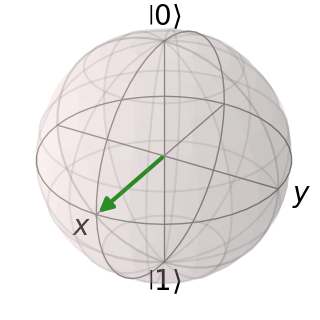

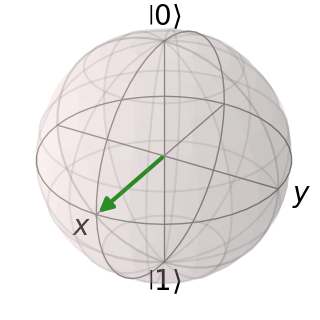

In [3]:
# Example: state along the X-axis
theta = np.pi / 2 #theta: angle from the z-axis [0, pi]
phi = 0  #  phi: azimuthal angle [0, 2pi]
psi = cqd.utility.create_qubit_state(theta, phi)
# Visualize on the Bloch sphere
b = Bloch(figsize=(3, 3))
b.add_states(psi)
b.show()

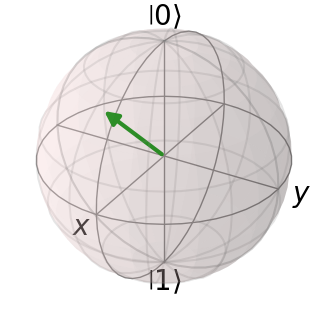

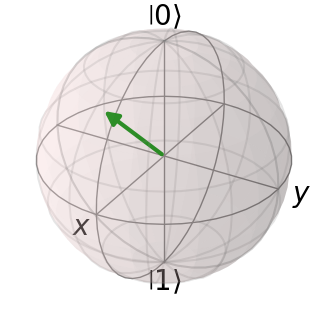

In [4]:
#state 
theta = np.pi / 4
phi = 270
psi = cqd.utility.create_qubit_state(theta, phi)
# Visualize on the Bloch sphere
#Bloch visualization
b = Bloch(figsize=(3, 3))
b.add_states(psi)
b.show()

In [5]:
#Pauli-operators
H = cqd.hamiltonians.hermitian_operator(1, 0.5, 0.2, -1)
print("H=\n", H)
print()
# Hermitian conjugate
H_dagger = H.conj().T
print("H† =\n", H_dagger)
print()
# Check equality
print(np.allclose(H, H_dagger))

H=
 [[0. +0.j  0.5-0.2j]
 [0.5+0.2j 2. +0.j ]]

H† =
 [[0. -0.j  0.5-0.2j]
 [0.5+0.2j 2. -0.j ]]

True


In [6]:
#Pauli-operators
H = cqd.hamiltonians.hermitian_operator(1, 0, 0, 1)
print("H=\n", H)
print()
# Hermitian conjugate
H_dagger = H.conj().T
print("H† =\n", H_dagger)
print()
# Check equality
print(np.allclose(H, H_dagger))

H=
 [[2.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

H† =
 [[2.-0.j 0.-0.j]
 [0.-0.j 0.-0.j]]

True


In [7]:
#Pauli-operators
H = cqd.hamiltonians.hermitian_operator(1, 1, 1, 1)
print("H=\n", H)
print()
# Hermitian conjugate
H_dagger = H.conj().T
print("H† =\n", H_dagger)
print()
# Check equality
print(np.allclose(H, H_dagger))

H=
 [[2.+0.j 1.-1.j]
 [1.+1.j 0.+0.j]]

H† =
 [[2.-0.j 1.-1.j]
 [1.+1.j 0.-0.j]]

True


Rx:
 [[0.8660254+0.j  0.       -0.5j]
 [0.       -0.5j 0.8660254+0.j ]]
Initial state = [1 0]

Evolved state = [ 0.72827555-0.58913884j -0.27214547+0.2201522j ]


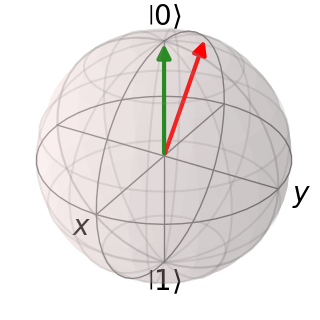

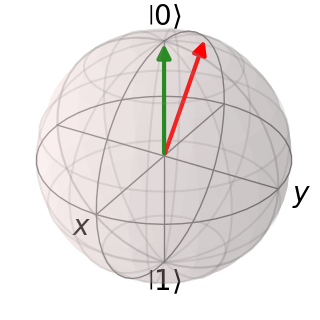

In [8]:
# Parameters
Omega = 1
t = np.pi / 2
theta = np.pi / 3  
axis = [1, 0, 0] 
Rx = bs.operators.rotation_gate(theta, axis)
print("Rx:\n", Rx)
# Hamiltonian
H = (Omega / 2) * Rx

# Unitary evolution 
U = expm(-1j * H * t)

# Initial state 
psi0 = np.array([1, 0])
psi_t = U @ psi0/np.linalg.norm(U @ psi0) #normalized the sate 

# Time evolved state
print("Initial state =", psi0)
print()
print("Evolved state =", psi_t)



# Convert to Qobj for Bloch visualization
initial_Qobj = qt.Qobj(psi0)
final_Qobj = qt.Qobj(psi_t)

# Bloch sphere
b = Bloch(figsize=(3,3))
b.add_states([initial_Qobj, final_Qobj])
b.vector_color = ['green', 'red']
b.show()

Ry=
 [[ 0.92387953+0.j -0.38268343+0.j]
 [ 0.38268343+0.j  0.92387953+0.j]]
Initial state=
 [0 1]

Evolved state=
 [0.09021806+0.17172074j 0.86844597-0.4562612j ]


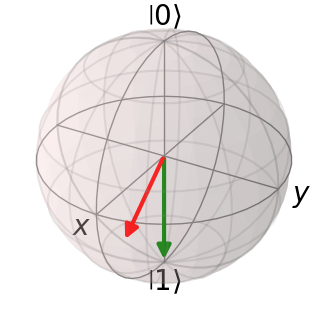

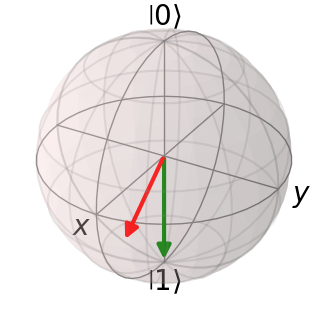

In [9]:
# Parameters
Omega = 1
t = np.pi / 3
theta = np.pi / 4  
axis=[0, 1, 0]
Ry = bs.operators.rotation_gate(theta, axis)
print("Ry=\n", Ry)

# Hamiltonian 
H = (Omega / 2) * Ry

# Unitary evolution operator
U = expm(-1j * H * t)

#state
psi0 = np.array([0, 1])
psi_t = U @ psi0/np.linalg.norm(U @ psi0) 

print("Initial state=\n", psi0)
print()
print("Evolved state=\n", psi_t)
# Convert to Qobj for Bloch visualization
initial_Qobj= qt.Qobj(psi0)
final_Qobj= qt.Qobj(psi_t)

# Bloch sphere
b = Bloch(figsize=(3, 3))
b.add_states([initial_Qobj, final_Qobj])
b.vector_color = ['green', 'red']
b.show()

Rz=
 [[0.92387953-0.38268343j 0.        +0.j        ]
 [0.        +0.j         0.92387953+0.38268343j]]
Initial state=
 [0 1]

Evolved state=
 [0.        +0.j         0.74809259-0.66359436j]


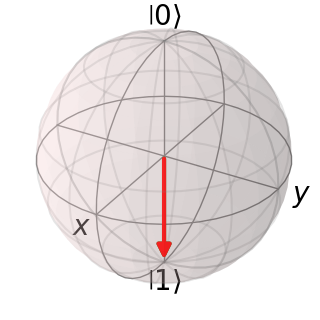

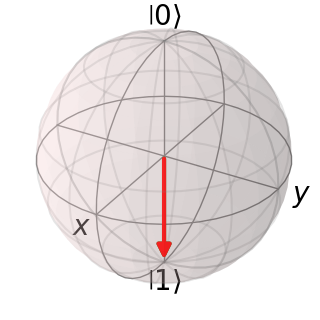

In [10]:
# Parameters
Omega = 1
t = np.pi / 2
theta = np.pi / 4  
axis=[0, 0, 1]
Rz = bs.operators.rotation_gate(theta, axis)
print("Rz=\n", Rz)

# Hamiltonian 
H = (Omega / 2) * Rz

# Unitary evolution operator
U = expm(-1j * H * t)

#state
psi0 = np.array([0, 1])
psi_t = U @ psi0/np.linalg.norm(U @ psi0)

print("Initial state=\n", psi0)
print()
print("Evolved state=\n", psi_t)
# Convert to Qobj for Bloch visualization
initial_Qobj= qt.Qobj(psi0)
final_Qobj= qt.Qobj(psi_t)

# Bloch sphere
b = Bloch(figsize=(3, 3))
b.add_states([initial_Qobj, final_Qobj])
b.vector_color=['green', 'red']
b.show()